# Finding windfarms using SAR

__Description & purpose__: This Notebook is presented as a simple way to start processing Sentinel 1 synthetic aperture radar (SAR) data. 

<style>
.scibtn {
  background-color: #04AA6D;
  color: white;
  font-size: 15px;
  padding: 12px;
  border: none;
  border-radius: 5px;
  cursor: pointer;
}
.howbtn {
  background-color: #0407aaff;
  color: white;
  font-size: 15px;
  padding: 12px;
  border: none;
  border-radius: 5px;
  cursor: pointer;
}
.databtn {
  background-color: #edfd03ff;
  color: black;
  font-size: 15px;
  padding: 12px;
  border: none;
  border-radius: 5px;
  cursor: pointer;
}

</style>

<button class="scibtn">Science</button> &nbsp; <button class="databtn">Satellite</button>

In [1]:
# Run this cell if pyeodh is not installed, or needs updating
%pip install --upgrade pyeodh
%pip install shapely rasterio scipy scikit-image matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


The premise of this notebook is that the user needs to undertake the following steps:
* Find the SAR data in the Resource Catalogue
* Clip the data to a wider area of interest (AOI)
* Perform a simple analysis of the data inside the wider AOI
* Extract and count any likely wind turbines
* Display the resulting data

In [2]:
# Import the Python API Client
import pyeodh

# Import all other packages
import numpy as np
import matplotlib.pyplot as plt

from rasterio.warp import transform_geom
from rasterio.mask import mask
import rasterio.features
from rasterio.features import geometry_mask

import shapely.geometry

from scipy.ndimage import uniform_filter
from skimage.feature import blob_log


Having done the required package imports we need to connect to the EODH platform.

In [3]:
# Connect to the Hub

client = pyeodh.Client(
    base_url="https://eodatahub.org.uk"
).get_catalog_service()


# We want to use the CEDA Sentinel 1 ARD
s1ard_cat = client.get_catalog("public/catalogs/ceda-stac-catalogue").get_collection('sentinel1_ard')

print("id: ", s1ard_cat.id)
print("title: ", s1ard_cat.title)
print("description: ", s1ard_cat.description)

id:  sentinel1_ard
title:  Sentinel 1 ARD
description:  These data have been created by the Department for Environment, Food and Rural Affairs (Defra) and Joint Nature Conservation Committee (JNCC) in order to cost-effectively provide high quality, Analysis Ready Data (ARD) for a wide range of applications. The dataset contains modified Copernicus Sentinel-1 IW GRDH products processed using the ESA SNAP toolbox.


The Hub API endpoints are wrapped in methods inside `pyeodh` and are structured into classes, following the same logic as the underlying APIs. This means that, for example, to fetch a collection item we first need to get the collection from the resource catalogue. The following cell provedes a code example to do this. 

In [4]:
s1ard = client.get_catalog("public/catalogs/ceda-stac-catalogue").get_collection('sentinel1_ard')
items = s1ard.get_items()

The next thing to do is define the site and time range. We are going to use a point that is in the Irish sea just off the North Wales coast, and we are going to look for a single date. The date range could be altered to return multiple STAC items from the Resource Catalogue, but for this example we are only interested in a single date.

In [5]:
# Define the site
lon, lat =  (-3.4713815271134365, 53.51518976947992)
wf_pnt = shapely.Point(lon, lat) 


items = client.search(
    collections=['sentinel1_ard'],
    catalog_paths=["public/catalogs/ceda-stac-catalogue"],
    intersects = wf_pnt,
    query=[
        'start_datetime>=2026-03-14',
        'end_datetime<=2026-03-14',
    ],
)

# We can then count the number of items returned by the search 

total_items = sum(1 for _ in items)
print(f"Total items: {total_items}")

Total items: 1


We can show some information about the returned item.

In [6]:
for item in items[:]:  
    print(f"Item ID: {item.id}")
    print("Assets:")
    
    if not item.assets:
        print("  No assets available.")
    else:
        for asset_key, asset in item.assets.items():
            print(f"  - {asset_key}: {asset.to_dict()}")  # Convert asset to dict for readable output
            print("-" * 40)  # Separator for better readability

Item ID: neodc.sentinel_ard.data.sentinel_1.2026.03.14.S1A_20260314_30_asc_175827_175852_VVVH_G0_GB_OSGB_RTCK_SpkRL
Assets:
  - data: {'href': 'https://dap.ceda.ac.uk/neodc/sentinel_ard/data/sentinel_1/2026/03/14/S1A_20260314_30_asc_175827_175852_VVVH_G0_GB_OSGB_RTCK_SpkRL.tif', 'type': 'image/tiff; application=geotiff', 'size': 3938349006, 'location': 'on_disk', 'roles': ['data']}
----------------------------------------
  - metadata: {'href': 'https://dap.ceda.ac.uk/neodc/sentinel_ard/data/sentinel_1/2026/03/14/S1A_20260314_30_asc_175827_175852_VVVH_G0_GB_OSGB_RTCK_SpkRL_meta.xml', 'type': 'application/xml', 'size': 17002, 'location': 'on_disk', 'roles': ['metadata']}
----------------------------------------


We can see from the `Assets: data: href` information that the dataset corresponds to the image data held in the Hub at [https://dap.ceda.ac.uk/neodc/sentinel_ard/data/sentinel_1/2026/03/14/S1A_20260314_30_asc_175827_175852_VVVH_G0_GB_OSGB_RTCK_SpkRL.tif](https://dap.ceda.ac.uk/neodc/sentinel_ard/data/sentinel_1/2026/03/14/S1A_20260314_30_asc_175827_175852_VVVH_G0_GB_OSGB_RTCK_SpkRL.tif). You can also use the location and date range to search for the same data item using the Resource Catalogue online user interface.

The next thing that we will do is define our working boundaries. This confines us to:
* a larger area (geojson_outer) that is used to run the analysis, and
* a smaller are (known to contain a windfarm) to help demonstrate the visualisation and analytical properties of this methodology.

First we define each area in the cells below. If you want see where these areas are you can copy the text between the outer braces {} in each cell and paste it into [https://geojson.io/](https://geojson.io/)

In [7]:
geojson_outer = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "coordinates": [
          [
            [
              -3.8866599373691884,
              53.79029338852189
            ],
            [
              -3.8866599373691884,
              53.34336271949496
            ],
            [
              -3.1835350027603795,
              53.34336271949496
            ],
            [
              -3.1835350027603795,
              53.79029338852189
            ],
            [
              -3.8866599373691884,
              53.79029338852189
            ]
          ]
        ],
        "type": "Polygon"
      }
    }
  ]
}

In [8]:
geojson_inner = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "coordinates": [
          [
            [
              -3.7536500849122376,
              53.60931600777363
            ],
            [
              -3.7536500849122376,
              53.3663576707672
            ],
            [
              -3.221229947714505,
              53.3663576707672
            ],
            [
              -3.221229947714505,
              53.60931600777363
            ],
            [
              -3.7536500849122376,
              53.60931600777363
            ]
          ]
        ],
        "type": "Polygon"
      }
    }
  ]
}

The first thing to do is clip the asset to the larger AOI. 


<style>
.howbtn {
  background-color: #f7871fff;
  color: white;
  font-size: 15px;
  padding: 12px;
  border: none;
  border-radius: 5px;
  cursor: pointer;
}
</style>

<button class="howbtn">How-to Highlight</button>

In [9]:
# Extract geometry list (what rasterio expects)
geoms = [feature["geometry"] for feature in geojson_outer["features"]]

# Your STAC asset URL (GeoTIFF)
url = item.assets["data"].href

with rasterio.open(url) as src:
    geoms_proj = [
        transform_geom("EPSG:4326", src.crs, geom)
        for geom in geoms
    ]

    out_image, out_transform = mask(src, geoms_proj, crop=True)

    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })


To define the scattering objects in the image (wind turbines) we need to find those features in the clipped image. A simple way to do this is to create a dataset relating to the local standard deviation. If this work was being undertaken operationally we recommend that you learn about and implement more robust methods based on temporal data processing, but for this demonstration this method is sufficient. 

In [10]:
# find features in clipped image

img = out_image[0]

# Local mean
mean = uniform_filter(img, size=15)

# Local squared mean
mean_sq = uniform_filter(img**2, size=15)

# Local variance
var = mean_sq - mean**2
std = np.sqrt(var)

We can visualise the outcome of that calculation using the following code.

_Note_: This method generates edge effects where the image has been clipped. To remove these from the final dataset and visualiseation we use the inner AOI to crop to the windfarm we are interested in.

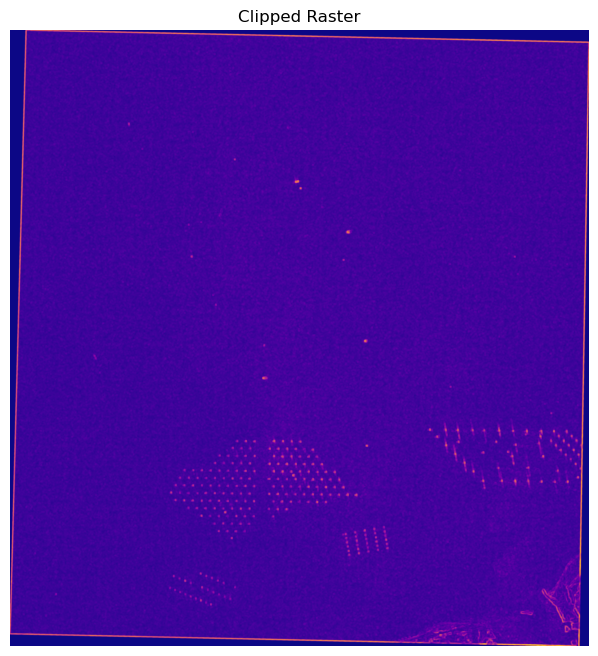

In [11]:
# ---- Plot ----
plt.figure(figsize=(8, 8))

# If multi-band (e.g. Sentinel-1 VV/VH), pick a band:
plt.imshow(std, cmap="plasma")

plt.title("Clipped Raster")
plt.axis("off")
plt.show()

In [12]:
# Clip to the smaller AOI

geoms = [feature["geometry"] for feature in geojson_inner["features"]]

geoms_proj = [
    transform_geom("EPSG:4326", src.crs, geom)
    for geom in geoms
]

mask = geometry_mask(
    geoms_proj,
    transform=out_transform,
    invert=True,              # keep inside polygon
    out_shape=out_image.shape[1:]  # (rows, cols)
)

clipped = np.where(mask, std, np.nan)


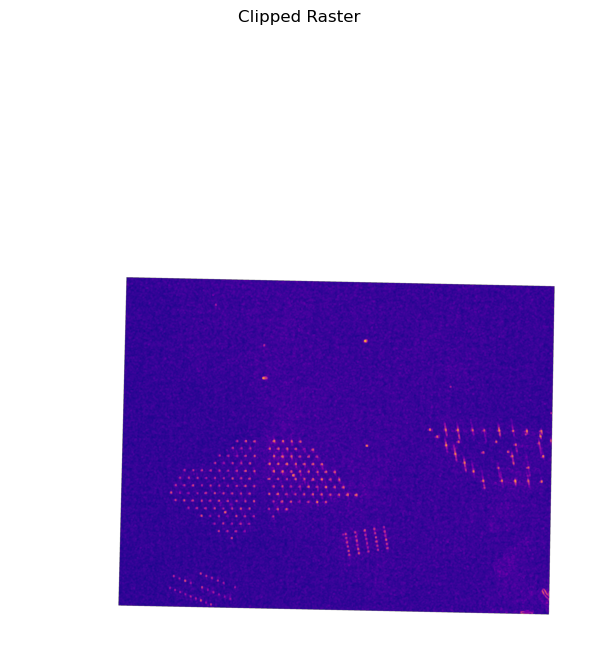

In [13]:
# ---- Plot ----
plt.figure(figsize=(8, 8))

# If multi-band (e.g. Sentinel-1 VV/VH), pick a band:
plt.imshow(clipped, cmap="plasma")

plt.title("Clipped Raster")
plt.axis("off")
plt.show()

The final task is to get a rough count of the wind turbines in the image (_note_: this quick pass assessment will likely also find non-turbine objects, but the majority of features extracted will relate to turbines). First we use SciKit Image to find the bright "blobs" in the AOI.


<style>
.howbtn {
  background-color: #f7871fff;
  color: white;
  font-size: 15px;
  padding: 12px;
  border: none;
  border-radius: 5px;
  cursor: pointer;
}
</style>

<button class="howbtn">How-to Highlight</button>

In [14]:
blobs = blob_log(
    clipped,
    min_sigma=2,
    max_sigma=8,
    num_sigma=10,
    threshold=0.8
)

If we return the size of that dataset then we have a rough idea of the number of turbines.

In [15]:
print(len(blobs))

343


We can plot the blobs over the background image so that we can see where the possible turbines are. The data shown below relates to Gwynt-y-Mor and surrounding windfarms. These blobs could then be exported as a file for use in a GIS system.

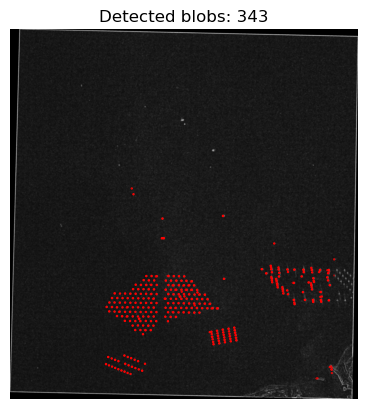

In [16]:
import matplotlib.pyplot as plt

plt.imshow(std, cmap='gray')

for y, x, r in blobs:
    c = plt.Circle((x, y), r, color='red', linewidth=1, fill=False)
    plt.gca().add_patch(c)

plt.title(f"Detected blobs: {len(blobs)}")
plt.axis('off')
plt.show()

---

__Author(s)__: Alastair Graham

__Date created__: 2026-03-20

__Date last modified__: 2026-03-23

__Licence__: This notebook is licensed under Creative Commons Attribution-ShareAlike 4.0 International. The code is released using the BSD-2-Clause license.

<span style="font-size:0.65em;">
Copyright &copy; - All rights reserved.

Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met:

Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer. Redistributions in binary form must reproduce the above copyright notice, this list of conditions and the following disclaimer in the documentation and/or other materials provided with the distribution. THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS “AS IS” AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.</span>
